In [1]:
import sys, os
sys.path.insert(0, "/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX")
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

from tensorflow_probability.substrates import jax as tfp
# Import JAX and require double precision.
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
dtype = jnp.float64

# Other tools.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
# Import TriplePandel stuff
from lib.simdata_i3 import I3SimHandler
from lib.geo import center_track_pos_and_time_based_on_data
from lib.gupta_network_eqx_4comp import get_network_eval_v_fn, get_network_eval_v_fn_f32
from lib.experimental_methods import get_vertex_seeds
from fitting.llh_scanner import get_scanner
from fitting.llh_fitter import get_fitter
from dom_track_eval import get_eval_network_doms_and_track
from likelihood_conv_mpe_logsumexp_gupta import get_neg_c_triple_gamma_llh

# A custom color scheme
from palettable.cubehelix import Cubehelix
cx = Cubehelix.make(start=0.3, rotation=-0.5, n=16, reverse=False, gamma=1.0,
     	max_light=1.0,max_sat=0.5, min_sat=1.4).get_mpl_colormap()

# Specify the grid.
dzen = 0.07 # rad
dazi = 0.07 # rad
n_eval = 50 # number of grid points per axes

# Assume 4-component gupta by default
n_hidden = 96
gupta = True
n_comp = 4

2025-10-08 17:44:51.665195: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
network_path = '/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX/data/gupta/n96_4comp/new_model_no_penalties_tree_start_epoch_800.eqx'

In [3]:
try:
    ni = "f64"
    print("Running f64 model")
    eval_network_v = get_network_eval_v_fn(bpath=network_path, dtype=dtype, n_hidden=n_hidden)
except:
    ni = "f32"
    print("Running f32 model")
    eval_network_v = get_network_eval_v_fn_f32(bpath=network_path, dtype=dtype, n_hidden=n_hidden)

eval_network_doms_and_track = get_eval_network_doms_and_track(eval_network_v, dtype=dtype, gupta=gupta, n_comp=n_comp)

Running f64 model


2025-10-08 17:44:59.176149: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.6 which is older than the PTX compiler version (12.9.86). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [4]:
PATH_TO_INPUT = '/mnt/research/IceCube/Gupta-Reco/22645/tfrecords/ftr/'
META_FILE_NAME = 'meta_ds_22645_from_0_to_1000_10_to_100TeV.ftr'
PULSES_FILE_NAME = 'pulses_ds_22645_from_0_to_1000_10_to_100TeV.ftr'

In [5]:
def get_event_data(event_index: int) -> pd.DataFrame:
    ev_idx = event_index
    event_meta = events_meta.iloc[ev_idx]
    print(event_meta)
    event_id = event_meta['event_id']
    
    event_data = events_data[events_data['event_id'] == event_id].copy()
    return event_meta, event_data

In [6]:
def get_per_dom_summary_from_sim_data(
    meta: pd.DataFrame,
    pulses: pd.DataFrame,
    charge_key='charge',
    correct_charge=False) -> pd.DataFrame:

    df_qtot = pulses[['sensor_id', charge_key]].groupby(by=['sensor_id'], as_index=False).sum()
    df_tmin = pulses[['sensor_id', 'time']].groupby(by=['sensor_id'], as_index=False).min()
    df = df_qtot.merge(geo.iloc[df_qtot['sensor_id']], on='sensor_id', how='outer')
    df['time'] = df_tmin['time'].values

    if correct_charge == True:
        df_corr = pulses[['sensor_id', 'charge_correction']].groupby(by=['sensor_id'], as_index=False).mean()
        df['charge'] = df['charge'].values * df_corr['charge_correction'].values

    if charge_key != 'charge':
        df.rename({charge_key: 'charge'}, inplace=True, axis='columns')
    return df

In [7]:
def replace_early_pulse(summary_data, pulses):
    corrected_time = np.zeros(len(summary_data))
    for i, row in summary_data.iterrows():
        s_id = row['sensor_id']
        q_tot = row['charge']
        t1 = row['time']

        idx = pulses['sensor_id'] == s_id
        pulses_this_dom = pulses[idx]
        corrected_time[i] = get_first_regular_pulse(pulses_this_dom, t1, q_tot)



    summary_data['time'] = corrected_time

In [8]:
def get_first_regular_pulse(pulses, t1, q_tot, crit_delta=10, crit_ratio = 5.e-3, crit_charge=100.):
    # technically, if we do remove early pulses, one could correct the total charge.
    # in practice, this would be an epsilon correction. Not worth adding the extra code complexity.
    # calculate ratio of charge within 10ns and 75ns of hit.
    if q_tot < crit_charge:
        return t1

    n = len(pulses)
    charge = pulses['charge'].to_numpy()
    time = pulses['time'].to_numpy()
    crit_delta_long = 75

    j = 0 # pts to end of crit_delta interval
    k = 0 # pts to end of crit_delta_long interval
    q_veto = 0
    q_long = 0
    for i in range(0, n):
        crit_time = time[i] + crit_delta
        if j < i:
            j = i

        # extend window
        while j < n and time[j] < crit_time:
            q_veto += charge[j]
            j += 1

        crit_time = time[i] + crit_delta_long
        if k < i:
            k = i

        # extend window
        while k < n and time[k] < crit_time:
            q_long += charge[k]
            k += 1

        r_veto = q_veto / q_long
        if r_veto > crit_ratio:
            # found a reasonable pulse
            # break
            break

        # remove early pulse
        q_long -= charge[i]
        q_veto -= charge[i]

    return time[i]

In [11]:
def plot_event(df, index, geo=None, outfile=None, plot_pdf=None):
    fig = plt.figure(figsize=(12,8))
    ax = plt.subplot(projection='3d')
    ax.set_xlabel('pos.x [m]', fontsize=16, labelpad=-25)
    ax.set_ylabel('pos.y [m]', fontsize=16, labelpad=-25)
    ax.set_zlabel('pos.z [m]', fontsize=16, labelpad=-25)

    try:
        im = ax.scatter(geo['x'], geo['y'], geo['z'], s=0.9, c='0.7', alpha=0.8)
    except:
        pass

    im = ax.scatter(df['x'], df['y'], df['z'], s=np.sqrt(df['charge']*100), c=df['time'],
                    cmap='rainbow_r',  edgecolors='k', zorder=1000)
    ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
    cb = plt.colorbar(im, orientation="vertical", pad=0.1)
    cb.set_label(label='time [ns]', size='x-large')
    cb.ax.tick_params(labelsize='x-large')
    plt.title(f'Event {index}')
    if plot_pdf:
        pdf.savefig()
        plt.close()
    else:
        plt.show()
    # if outfile is None:
    #     plt.show()

    # else:
    #     plt.savefig(outfile, dpi=300)

event_id                   226450000002879.0
idx_start                                0.0
idx_end                                267.0
n_channel_HLC                           56.0
neutrino_energy                242924.656839
muon_energy                    163396.468533
muon_energy_at_detector          5937.374564
muon_energy_lost                -9862.668558
q_tot                             304.350001
n_channel                               68.0
muon_zenith                         2.113079
muon_azimuth                        2.383201
muon_time                       -3365.406031
muon_pos_x                      -2691.248177
muon_pos_y                       2798.425069
muon_pos_z                      -1876.434304
spline_mpe_zenith                   2.115589
spline_mpe_azimuth                  2.381282
spline_mpe_time                 10274.554238
spline_mpe_pos_x                 -149.069579
spline_mpe_pos_y                  389.626615
spline_mpe_pos_z                  233.588839
Name: 2, d

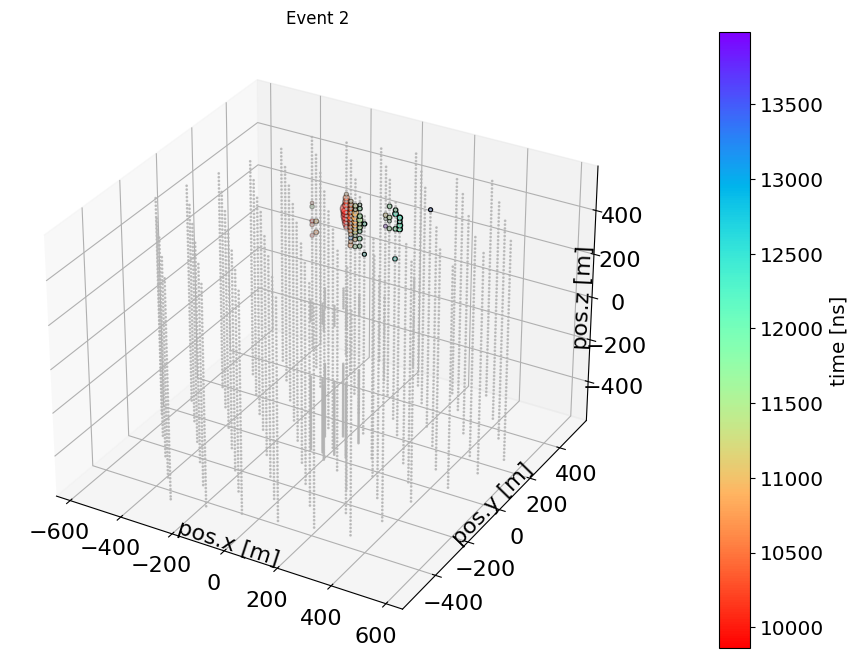

In [12]:
EVENT_INDEX=2
geo_file = '/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX/data/icecube/detector_geometry.csv'
geo = pd.read_csv(geo_file)

events_meta_file = os.path.join(PATH_TO_INPUT, META_FILE_NAME)
events_pulses_file = os.path.join(PATH_TO_INPUT, PULSES_FILE_NAME)
geo_file = '/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX/data/icecube/detector_geometry.csv'

events_meta = pd.read_feather(events_meta_file)
events_data = pd.read_feather(events_pulses_file)
geo = pd.read_csv(geo_file)


int_cols_meta = ["event_id", "idx_start", "idx_end", "n_channel_HLC", "n_channel"]
events_meta[int_cols_meta] = events_meta[int_cols_meta].astype("Int64")

int_cols_data = ["event_id", "sensor_id", "is_HLC"]
events_data[int_cols_data] = events_data[int_cols_data].astype("Int64")

meta, pulses = get_event_data(EVENT_INDEX)
print(f"muon energy: {meta['muon_energy_at_detector']/1.e3:.1f} TeV")

# Get dom locations, first hit times, and total charges (for each dom).
event_data = get_per_dom_summary_from_sim_data(meta, pulses)

# Remove early pulses.
replace_early_pulse(event_data, pulses)
print("n_doms", len(event_data))

# Get MCTruth.
true_pos = jnp.array([meta['muon_pos_x'], meta['muon_pos_y'], meta['muon_pos_z']])
print(true_pos)
true_time = meta['muon_time']
true_zenith = meta['muon_zenith']
true_azimuth = meta['muon_azimuth']
true_src = jnp.array([true_zenith, true_azimuth])
true_src_deg = np.rad2deg(true_src)
print("true direction:", true_src)
print("true direction:", true_src_deg)
plot_event(event_data, EVENT_INDEX, geo=geo)

In [13]:
SEED =  "spline_mpe"
if SEED == "spline_mpe":
    # Use SplineMPE as a seed.
    track_pos = jnp.array([meta['spline_mpe_pos_x'], meta['spline_mpe_pos_y'], meta['spline_mpe_pos_z']])
    track_time = meta['spline_mpe_time']
    track_zenith = meta['spline_mpe_zenith']
    track_azimuth = meta['spline_mpe_azimuth']
    track_src = jnp.array([track_zenith, track_azimuth])

elif SEED == "truth":
    track_pos = true_pos
    track_time = true_time
    track_zenith = true_zenith
    track_azimuth = true_azimuth
    track_src = true_src

In [14]:
print("seed direction:", np.rad2deg(track_src), "deg")
print("original seed vertex:", track_pos, "m")

center_track_seed = True

centered_track_pos, centered_track_time = track_pos, track_time
if center_track_seed:
    print("shifting seed vertex.")
    centered_track_pos, centered_track_time = center_track_pos_and_time_based_on_data(event_data, track_pos, track_time, track_src)

print("seed vertex:", centered_track_pos, "m")

fitting_event_data = jnp.array(event_data[['x', 'y', 'z', 'time', 'charge']].to_numpy())
print(fitting_event_data.shape)

seed direction: [121.2143047  136.43741659] deg
original seed vertex: [-149.0695786   389.62661526  233.58883862] m
shifting seed vertex.
seed vertex: [-112.17413692  354.53747668  264.44253043] m
(68, 5)


In [15]:
GAUS_CONV_WIDTH = 3.0
neg_llh = get_neg_c_triple_gamma_llh(eval_network_doms_and_track, sigma=GAUS_CONV_WIDTH)

In [16]:
use_multiple_vertex_seeds = True
prescan_time = True
fit_llh = get_fitter(
                        neg_llh,
                        use_multiple_vertex_seeds=use_multiple_vertex_seeds,
                        prescan_time=prescan_time
                    )

# JIT! We want it to be fast.
fit_llh_jit = jax.jit(fit_llh)

# Run the fit
solution = fit_llh_jit(track_src, centered_track_pos, centered_track_time, fitting_event_data)
best_logl, best_direction, best_vertex, best_time= solution

print("")
print("solution found.")
print(f"logl: {best_logl:.3f}")
print(f"direction: {np.rad2deg(best_direction)} deg")
print("")


solution found.
logl: 832.267
direction: [121.16793017 136.51577418] deg



In [17]:
N_SPLITS = 50

scan_llh = get_scanner(
                        neg_llh,
                        use_multiple_vertex_seeds=use_multiple_vertex_seeds,
                        prescan_time=prescan_time,
                        n_splits=N_SPLITS,
                        use_jit=True
                    )

zenith = jnp.linspace(true_src[0]-dzen, true_src[0]+dazi, n_eval)
azimuth = jnp.linspace(true_src[1]-dzen, true_src[1]+dazi, n_eval)
X, Y = jnp.meshgrid(zenith, azimuth)

print("running the scan.")

running the scan.


In [18]:
solution = scan_llh(X, Y, best_vertex, best_time, fitting_event_data)
# use below if you want to use original seed values (not best-fit values)
# as seed for vertex minimization during scan.
# solution = scan_llh(X, Y, centered_track_pos, centered_track_time, fitting_event_data)

sol_logl, sol_vertex, sol_time = solution
logls = sol_logl.reshape(X.shape)

2025-10-08 17:48:10.429703: W external/xla/xla/tsl/framework/bfc_allocator.cc:482] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.62GiB (rounded to 8179609344)requested by op 
2025-10-08 17:48:10.429826: W external/xla/xla/tsl/framework/bfc_allocator.cc:494] *___________________________________________________________________________________________________
E1008 17:48:10.429850 2536637 pjrt_stream_executor_client.cc:3067] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 8179609208 bytes.


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 8179609208 bytes.

In [ ]:
# Plot.
fig, ax = plt.subplots()
min_logl = np.amin(logls)
delta_logl = logls - np.amin(logls)
pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=np.min([100, 1.2*np.amax(delta_logl)]), shading='auto', cmap=cx)
# pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, shading='auto', cmap=cx)
cbar = fig.colorbar(pc)
cbar.ax.tick_params(labelsize=16)
cbar.ax.get_yaxis().labelpad = 5
cbar.set_label("-2$\\Delta$log $L_{MPE}$", fontsize=20)
cbar.outline.set_linewidth(1.5)

contours = [4.61]
ix1, ix2 = np.where(delta_logl==0)
ax.scatter(np.rad2deg([X[ix1, ix2]]), np.rad2deg([Y[ix1, ix2]]), s=50, marker='o', facecolors='none', edgecolors='khaki', zorder=100., label='grid min')
ct = plt.contour(np.rad2deg(X), np.rad2deg(Y), delta_logl, levels=contours, linestyles=['solid'], colors=['khaki'], linewidths=1.0)

ax.scatter(np.rad2deg(true_src[0]), np.rad2deg(true_src[1]), marker="*", color='red', label="truth", zorder=200)
ax.scatter(np.rad2deg(track_src[0]), np.rad2deg(track_src[1]), marker="x", color='lime', label="seed", zorder=200)
ax.scatter(np.rad2deg(best_direction[0]), np.rad2deg(best_direction[1]), marker="x", color="magenta", label="best-fit", zorder=200)

ax.set_xlabel("zenith [deg]", fontsize=16)
ax.set_ylabel("azimuth [deg]", fontsize=16)
ax.set_xlim(np.rad2deg([true_src[0]-dzen, true_src[0]+dzen]))
ax.set_ylim(np.rad2deg([true_src[1]-dazi, true_src[1]+dazi]))
ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)

plt.legend()
plt.tight_layout()
# plt.savefig(f"f32_scan_ev_{EVENT_INDEX}.png", dpi=300)
# plt.savefig(f"{ni}_scan_ev_{EVENT_INDEX}.png", dpi=300)
plt.show()